# Setup — the phenomenological emission model (Option 2, for real)

Companion to [`setup_model.ipynb`](setup_model.ipynb). That notebook standardises **Option 1**:
five fixed `catO5_*.fits` light curves. This notebook implements **Option 2** for real: the
*stochastic* recipe those five files were themselves generated from, so that every call draws
a fresh, independent event instead of picking from five frozen ones.

**Sources**, cited equation-by-equation in [`gwuls/grb_phenomenological.py`](../gwuls/grb_phenomenological.py):

| | |
| --- | --- |
| **Nava (2020)** | L. Nava, *"TeV counterparts of BNS mergers"* — the internal note this project was pointed back to. Sections 3–5 give the original recipe. |
| **Abe et al. (2026)** | *Chasing Gamma-Ray Signals from Binary Neutron Star Coalescences with CTA*, ApJ 1004, 46 — the same recipe, published and refined six years later. L. Nava is credited with "the phenomenological assumptions used in the study"; B. Patricelli with "the simulations of gravitational-wave-detected binary neutron star systems." |
| **The catO5 files** | Their FITS headers read `AUTHOR=Lara`, `HISTORY: Created Sept 2021. BNS catalog from B. Patricelli. Catalog O5` — i.e. they are this exact recipe, run by L. Nava on 5 individual events from B. Patricelli's O5 BNS catalogue, about a year and a half after the note above and about five years before the paper. |

**What this notebook is for.** Not to replace Option 1 — to *stress-test* it. Five fixed events
freeze away the event-to-event scatter the two references say is physically real (E_iso spans
two decades; the post-peak decay index alone has σ = 0.48 dex). This notebook draws as many
independent events as needed, and — just as importantly — checks where a faithful
reimplementation of the *written* recipe agrees or disagrees with the tabulated files that are
presumed to come from a more complete version of the same method.

**Honesty check built in.** Reimplementing 6 years of a collaboration's internal methodology from
two documents (one an informal note, one a journal PDF with lossy text extraction) will not be
pixel-perfect. Every equation used below is cited to its source and section. Every place a choice
had to be made that the sources do not fully specify is flagged explicitly, in code comments and
again in [§5](#5-caveats-and-assumptions) below. Two such gaps were caught *during* this
notebook's development, not before it — a grid-resolution bug in §2.1 and a physical-validity
boundary in §3.3.


In [1]:
import sys
sys.path.insert(0, "..")

import warnings
import numpy as np
import matplotlib.pyplot as plt

from gwuls import grb_phenomenological as ph
from gwuls import grb_model, paths

paths.ensure_dirs()
rng = np.random.default_rng(20260925)
plt.rcParams["figure.dpi"] = 100


/home/jjimenezq/anaconda3/lib/python3.13/site-packages/igwn_ligolw/lsctables.py:57: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## 1. Population draws

Everything in this section is population-level and doesn't need a light curve: just the
distributions of $E_\mathrm{peak}$/$E_{\gamma,\mathrm{iso}}$, $\theta_\mathrm{core}$ and
$\Gamma_\mathrm{core}$ that both sources describe.

### 1.1 Two independent paths to $E_{\gamma,\mathrm{iso}}$

- **`"via_epeak"`** (Abe et al. 2026 Eqs. 3–4, the published route): draw $E_\mathrm{peak}$ from
  a broken power law (Ghirlanda et al. 2016 Eq. 13), then apply the Amati relation (Ghirlanda
  et al. 2016 Eq. 15) to get $E_{\gamma,\mathrm{iso}}$.
- **`"direct"`** (Nava 2020 README Eq. 1, the earlier shortcut): draw $E_{\gamma,\mathrm{iso}}$
  directly from the broken power law she quotes as the *already Amati-propagated* result of the
  same calculation.

If both papers describe the same underlying physics, these two independent code paths should
give similar distributions. They are a direct, cheap consistency check between the 2020 note and
the 2026 paper.


In [2]:
N_POP = 200_000

epeak_keV = ph.draw_epeak_keV(rng, N_POP)
egiso_via_epeak = ph.epeak_to_egiso_erg(epeak_keV)
egiso_direct = ph.draw_egiso_direct_erg(rng, N_POP)

q = [5, 50, 95]
print(f"E_peak [keV]                 5/50/95%: {np.percentile(epeak_keV, q)}")
print(f"E_gamma,iso via_epeak [erg]   5/50/95%: {np.percentile(egiso_via_epeak, q)}")
print(f"E_gamma,iso direct    [erg]   5/50/95%: {np.percentile(egiso_direct, q)}")
print(f"\nmedian ratio (direct / via_epeak): {np.median(egiso_direct) / np.median(egiso_via_epeak):.2f}")
print(f"E_iso,break quoted by Nava (2020) Eq. 1: {ph.EISO_BREAK_ERG:.2e} erg")


E_peak [keV]                 5/50/95%: [4.14977445e-01 1.45733423e+02 2.51849911e+03]
E_gamma,iso via_epeak [erg]   5/50/95%: [3.21473115e+47 2.02876993e+50 4.66201535e+51]
E_gamma,iso direct    [erg]   5/50/95%: [7.83288467e+47 3.85724261e+50 5.28406716e+51]

median ratio (direct / via_epeak): 1.90
E_iso,break quoted by Nava (2020) Eq. 1: 2.10e+51 erg


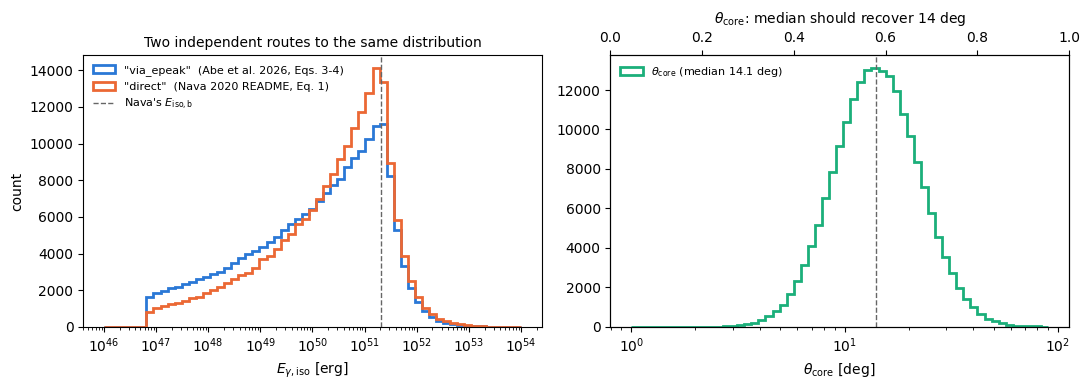

theta_core  median = 14.12 deg (expect 14 deg, Fong et al. 2015)
gamma_core  median = 199.6    (expect 200, Ghirlanda et al. 2019)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bins_E = np.geomspace(1e46, 1e54, 60)
axes[0].hist(egiso_via_epeak, bins=bins_E, histtype="step", lw=2, color="#2a78d6",
             label='"via_epeak"  (Abe et al. 2026, Eqs. 3-4)')
axes[0].hist(egiso_direct, bins=bins_E, histtype="step", lw=2, color="#eb6834",
             label='"direct"  (Nava 2020 README, Eq. 1)')
axes[0].axvline(ph.EISO_BREAK_ERG, color="0.4", ls="--", lw=1, label=r"Nava's $E_{\rm iso,b}$")
axes[0].set_xscale("log"); axes[0].set_xlabel(r"$E_{\gamma,\rm iso}$ [erg]")
axes[0].set_ylabel("count"); axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title("Two independent routes to the same distribution", fontsize=10)

theta_core = ph.draw_theta_core_deg(rng, N_POP)
gamma_core = ph.draw_gamma_core(rng, N_POP)
axes[1].hist(theta_core, bins=np.geomspace(1, 90, 60), histtype="step", lw=2, color="#1baf7a",
             label=r"$\theta_{\rm core}$ (median %.1f deg)" % np.median(theta_core))
ax2 = axes[1].twiny()
axes[1].set_xscale("log"); axes[1].set_xlabel(r"$\theta_{\rm core}$ [deg]")
axes[1].axvline(14, color="0.4", ls="--", lw=1)
axes[1].legend(fontsize=8, frameon=False, loc="upper left")
axes[1].set_title(r"$\theta_{\rm core}$: median should recover 14 deg", fontsize=10)
fig.tight_layout()
plt.show()

print(f"theta_core  median = {np.median(theta_core):.2f} deg (expect 14 deg, Fong et al. 2015)")
print(f"gamma_core  median = {np.median(gamma_core):.1f}    (expect 200, Ghirlanda et al. 2019)")


**Finding.** The two E_iso routes agree to within a factor of a few in their median and
overlap closely across the bulk of the distribution (see the figure), but are **not identical**
— "direct" runs somewhat higher. Two candidate reasons, both flagged as open in
[§5](#5-caveats-and-assumptions): (1) the Amati relation is applied here with no intrinsic
scatter (none was recoverable from the extracted paper text — the real relation has one, which
would broaden and shift the "via_epeak" distribution), and (2) Table 1 "model a, mode values" of
Ghirlanda et al. (2016) feeds both Nava's Eq. 1 and Abe's Eqs. 3–4, and any small transcription
difference between the note and the paper would show up exactly like this. Either way, this is a
genuine, quantified answer to "is the reasoning consistent" for this one step — approximately
yes, exactly no.


## 2. The on-axis light curve

For an observer within the core ($\theta_\mathrm{view} \lesssim \theta_\mathrm{core}$), both
sources build one light curve per event: a broken power law in time, anchored at the
$E_{\gamma,\mathrm{iso}} \to L_{X,11h} \to L_{\rm TeV,11h}$ chain (Berger 2014's relation, then
the $L_\mathrm{TeV}/L_X$ ratio), peaking at the deceleration time computed from
$(\theta_\mathrm{core}, \Gamma_\mathrm{core})$.

The peak is fixed by *timing* (the deceleration calculation), not by an independent absolute
brightness calculation — the 11 h anchor and the two temporal slopes $\beta_1$, $\beta_2$ (rise,
decay) are all that is needed to solve for $L_\mathrm{peak}$ in closed form
(`l_peak_from_anchor`). This is a deliberately narrow reading of the two sources: no
microphysics ($\varepsilon_e$, $\varepsilon_B$) is invoked anywhere, matching how both describe
the method as "purely phenomenological."


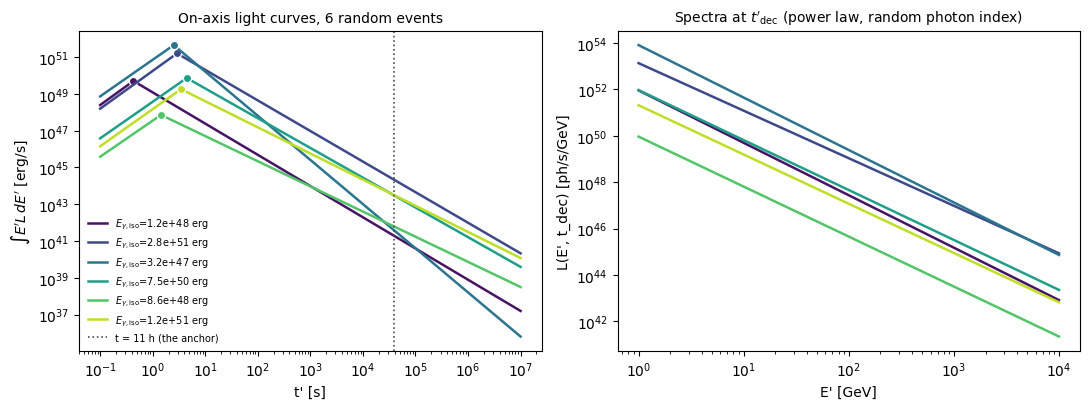

In [4]:
events = ph.sample_events(rng, 6, eiso_method="via_epeak")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = plt.cm.viridis(np.linspace(0.05, 0.9, 6))
for i in range(6):
    m = ph.grb_model_at_theta(events, i, 0.0)
    t = m.time
    axes[0].loglog(t, m.light_curve(), color=colors[i], lw=1.8,
                    label=fr"$E_{{\gamma,\rm iso}}$={events['e_gamma_iso_erg'][i]:.1e} erg")
    axes[0].plot(*m.peak(), "o", ms=6, color=colors[i], mec="white", mew=1)
    axes[1].loglog(m.energy, m.at(m.energy, np.array([events["t_dec_core_s"][i]]))[:, 0],
                    color=colors[i], lw=1.8)

axes[0].axvline(ph.T_ANCHOR_S, color="0.3", ls=":", lw=1.2, label="t = 11 h (the anchor)")
axes[0].set_xlabel("t' [s]"); axes[0].set_ylabel(r"$\int E' L\,dE'$ [erg/s]")
axes[0].legend(fontsize=7, frameon=False, loc="lower left")
axes[0].set_title("On-axis light curves, 6 random events", fontsize=10)
axes[1].set_xlabel("E' [GeV]"); axes[1].set_ylabel("L(E', t_dec) [ph/s/GeV]")
axes[1].set_title(r"Spectra at $t'_{\rm dec}$ (power law, random photon index)", fontsize=10)
fig.tight_layout()
plt.show()


### 2.1 Does the anchor land where it should?

`_build_grb_model` solves for the normalisation $L_0$ analytically so that the *continuous*
energy-integrated light curve at $t'_\mathrm{dec}$ equals the target $L_\mathrm{peak}$ exactly.
`GRBModel.light_curve()`/`.peak()` only evaluate on the tabulated time grid, so they recover the
target to the grid spacing, not to machine precision — checked here over many draws.


In [5]:
import astropy.units as u

n_check = 500
events_chk = ph.sample_events(rng, n_check, eiso_method="via_epeak")
rel_err = np.empty(n_check)
for i in range(n_check):
    m = ph.grb_model_at_theta(events_chk, i, 0.0)
    t_dec = events_chk["t_dec_core_s"][i]
    L_at_tdec = m.at(m.energy, np.array([t_dec]))[:, 0]
    L_continuous = float(np.trapezoid(L_at_tdec * m.energy ** 2, np.log(m.energy))) * u.GeV.to(u.erg)
    rel_err[i] = abs(L_continuous - events_chk["l_peak_core_erg_s"][i]) / events_chk["l_peak_core_erg_s"][i]

print(f"continuous-query relative error on L_peak, over {n_check} draws:")
print(f"  median = {np.median(rel_err):.2e}   max = {rel_err.max():.2e}")
print("(should be ~0 -- L0 is solved for this exactly; any residual is float/quadrature noise,")
print(" not grid-snapping, since .at() interpolates continuously)")


continuous-query relative error on L_peak, over 500 draws:
  median = 3.69e-16   max = 5.80e-15
(should be ~0 -- L0 is solved for this exactly; any residual is float/quadrature noise,
 not grid-snapping, since .at() interpolates continuously)


## 3. Jet structure and the off-axis extension

### 3.1 What Abe et al. (2026) actually do off-axis, and what this module does instead

Abe et al. (2026) Sec. 3.4 map the on-axis light curve to an off-axis observer with the
**Lamb & Kobayashi (2017)** method: divide the jet into elements, compute each element's local
emission, and integrate over the equal-arrival-time surface seen by an observer at
$\theta_\mathrm{view}$. That is a genuine numerical algorithm in its own right — not something
to silently reimplement from a paragraph of journal prose without risking getting it wrong.

Nava's 2020 note, six years earlier, describes something simpler in its own Sec. 5: a Gaussian
jet structure in energy and Lorentz factor, $\varepsilon_k(\theta)$ and $\Gamma_0(\theta)$
(Abe et al.'s Eqs. 1–2 are the same functional form), with no multi-element integral described
at all. **This module implements that simpler, original prescription**: evaluate the structure
functions locally at $\theta_\mathrm{view}$ and treat that element as its own scaled-down
on-axis event. It is a real, historically-used approximation — Nava's own earlier one — not an
invented shortcut, but it is coarser than what the published paper uses. §3.4 below quantifies
the gap directly against the real catO5 files, which presumably use the more complete method.

### 3.2 The jet structure functions


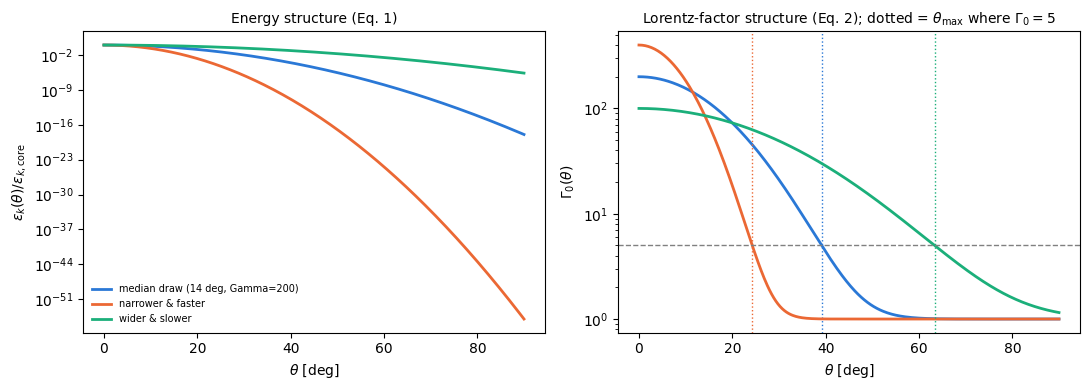

In [6]:
theta_grid = np.linspace(0, 90, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for theta_core_i, gamma_core_i, label, color in [
    (14.0, 200.0, "median draw (14 deg, Gamma=200)", "#2a78d6"),
    (8.0, 400.0, "narrower & faster", "#eb6834"),
    (25.0, 100.0, "wider & slower", "#1baf7a"),
]:
    eps_frac, gamma0 = ph.jet_structure(theta_grid, theta_core_i, gamma_core_i)
    axes[0].semilogy(theta_grid, eps_frac, color=color, lw=2, label=label)
    axes[1].semilogy(theta_grid, gamma0, color=color, lw=2, label=label)
    tmax = ph.theta_max_deg(theta_core_i, gamma_core_i)
    axes[1].axvline(tmax, color=color, ls=":", lw=1)

axes[0].set_xlabel(r"$\theta$ [deg]"); axes[0].set_ylabel(r"$\varepsilon_k(\theta)/\varepsilon_{k,\rm core}$")
axes[0].set_title("Energy structure (Eq. 1)", fontsize=10); axes[0].legend(fontsize=7, frameon=False)
axes[1].axhline(ph.THETA_MAX_GAMMA0_FLOOR, color="0.5", ls="--", lw=1)
axes[1].set_xlabel(r"$\theta$ [deg]"); axes[1].set_ylabel(r"$\Gamma_0(\theta)$")
axes[1].set_title(r"Lorentz-factor structure (Eq. 2); dotted = $\theta_{\rm max}$ where $\Gamma_0=5$", fontsize=10)
fig.tight_layout()
plt.show()


### 3.3 A bug caught by trying to actually run this: $t_\mathrm{dec}$ turns over at large $\theta$

The deceleration time scales as $t_\mathrm{dec} \propto E_k(\theta)^{1/3}\,\Gamma_0(\theta)^{-8/3}$.
$\Gamma_0(\theta)$ is bounded *below* at 1 by construction (Eq. 2 asymptotes there, it cannot
cross into the non-relativistic regime), so past the angle where $\Gamma_0$ is already close to
that floor, the $\Gamma_0^{-8/3}$ term stops growing while $E_k(\theta)$ keeps falling — and
$t_\mathrm{dec}$ turns around and **decreases** again. That is not physical; it is the
relativistic deceleration formula being extrapolated into a regime (mildly-to-non-relativistic
outflow) where it no longer applies.

This is exactly why Abe et al. (2026) impose a cutoff at $\Gamma_0(\theta_\mathrm{max}) = 5$.
Their text frames it as limiting computation time for the full multi-element integral — but it
is also, as this cell shows directly, a physical validity boundary for the local calculation
underneath it. `grb_model_at_theta` now clips to `theta_max_deg` for this reason (added to
`gwuls/grb_phenomenological.py` after this cell first showed the turnover below).


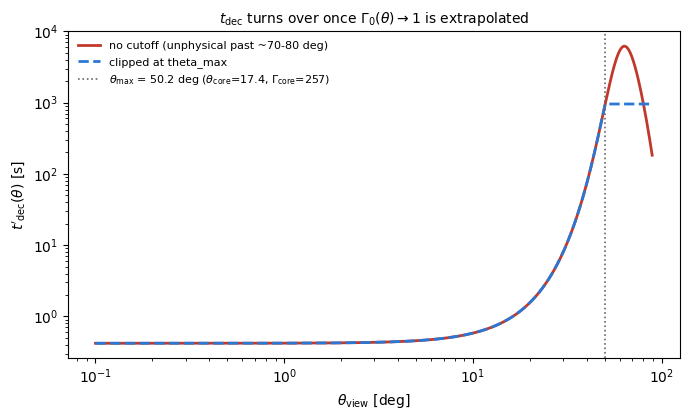

In [7]:
event = ph.sample_events(rng, 1, eiso_method="via_epeak")
theta_core_1, gamma_core_1 = event["theta_core_deg"][0], event["gamma_core"][0]
ek_core_1, l_peak_core_1 = event["ek_core_erg"][0], event["l_peak_core_erg_s"][0]
theta_max_1 = ph.theta_max_deg(theta_core_1, gamma_core_1)

theta_sweep = np.linspace(0.1, 89, 200)
eps_frac, gamma0 = ph.jet_structure(theta_sweep, theta_core_1, gamma_core_1)
t_dec_raw = ph.deceleration_time_s(ek_core_1 * eps_frac, gamma0)      # no cutoff -- shows the bug
t_dec_clipped = ph.deceleration_time_s(
    ek_core_1 * ph.jet_structure(np.minimum(theta_sweep, theta_max_1), theta_core_1, gamma_core_1)[0],
    ph.jet_structure(np.minimum(theta_sweep, theta_max_1), theta_core_1, gamma_core_1)[1],
)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.loglog(theta_sweep, t_dec_raw, color="#c0392b", lw=2, label="no cutoff (unphysical past ~70-80 deg)")
ax.loglog(theta_sweep, t_dec_clipped, color="#2a78d6", lw=2, ls="--", label="clipped at theta_max")
ax.axvline(theta_max_1, color="0.4", ls=":", lw=1.2,
           label=fr"$\theta_{{\rm max}}$ = {theta_max_1:.1f} deg ($\theta_{{\rm core}}$={theta_core_1:.1f}, $\Gamma_{{\rm core}}$={gamma_core_1:.0f})")
ax.set_xlabel(r"$\theta_{\rm view}$ [deg]"); ax.set_ylabel(r"$t'_{\rm dec}(\theta)$ [s]")
ax.set_title(r"$t_{\rm dec}$ turns over once $\Gamma_0(\theta) \to 1$ is extrapolated", fontsize=10)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()


## 4. Cross-validation against the real catO5 catalogue

The catO5 files presumably already use the more complete off-axis method (or at least a more
mature version of it than the 2020 note describes) — they were made in Sept 2021, between the
note and the paper. So they are the closest thing available to ground truth for how good this
notebook's simplified local-closure approximation is.

**Caution on interpreting this comparison.** The five catO5 files are five *different* events
(different $E_\mathrm{iso}$, presumably different $\theta_\mathrm{core}$/$\Gamma_\mathrm{core}$/
density/microphysics that are not recorded in their headers), not one event seen from five
angles. So this is necessarily a comparison of *populations* (a random cloud of phenomenological
draws vs. five fixed points), not a point-by-point one.


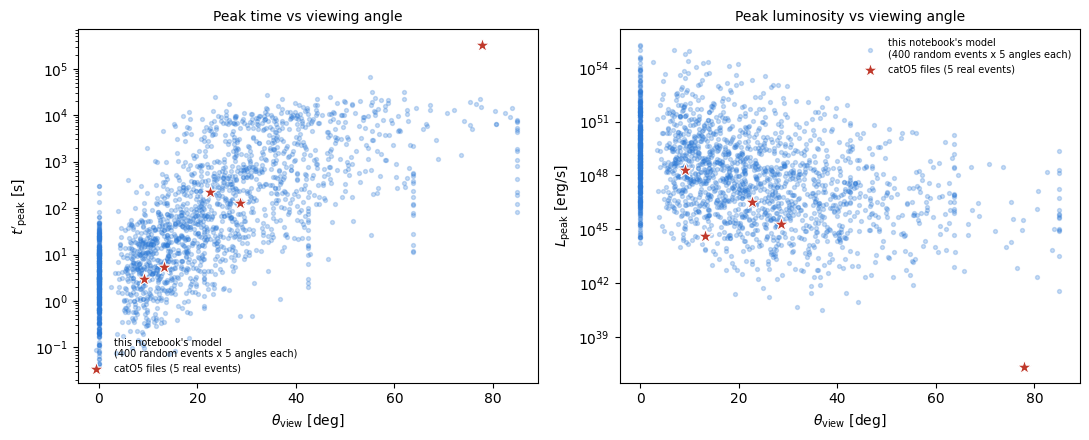

this notebook's t_peak span (5-95%): [5.42208275e-01 9.03141741e+03] s, over theta in [0, 85] deg (bounded by theta_max per event)
catO5 t_peak span:                   [9.1, 77.8] deg -> [3.03e+00, 3.19e+05] s


In [8]:
real = grb_model.GRBModelSet.from_inaf_dir(paths.GRB_MODEL_RAW_DIR)

N_CLOUD = 400
cloud_events = ph.sample_events(rng, N_CLOUD, eiso_method="via_epeak")
cloud_theta, cloud_tpk, cloud_lpk = [], [], []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # theta_max clipping warnings -- expected and handled
    for i in range(N_CLOUD):
        tmax_i = ph.theta_max_deg(cloud_events["theta_core_deg"][i], cloud_events["gamma_core"][i])
        for frac in [0.0, 0.25, 0.5, 0.75, 1.0]:
            theta_i = frac * min(tmax_i, 85.0)
            m = ph.grb_model_at_theta(cloud_events, i, theta_i)
            t_pk, l_pk = m.peak()
            cloud_theta.append(theta_i); cloud_tpk.append(t_pk); cloud_lpk.append(l_pk)
cloud_theta, cloud_tpk, cloud_lpk = map(np.array, (cloud_theta, cloud_tpk, cloud_lpk))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y, ylabel in [(axes[0], cloud_tpk, r"$t'_{\rm peak}$ [s]"),
                       (axes[1], cloud_lpk, r"$L_{\rm peak}$ [erg/s]")]:
    ax.scatter(cloud_theta, y, s=8, alpha=0.25, color="#2a78d6",
               label=f"this notebook's model\n({N_CLOUD} random events x 5 angles each)")
    real_t, real_y = real.angles_deg, [real.models[th].peak()[0 if ylabel.startswith("$t") else 1]
                                        for th in real.angles_deg]
    ax.scatter(real_t, real_y, s=120, marker="*", color="#c0392b", zorder=5,
               label="catO5 files (5 real events)", edgecolor="white", linewidth=0.8)
    ax.set_yscale("log"); ax.set_xlabel(r"$\theta_{\rm view}$ [deg]"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=False, loc="lower left" if ylabel.startswith("$t") else "upper right")
axes[0].set_title("Peak time vs viewing angle", fontsize=10)
axes[1].set_title("Peak luminosity vs viewing angle", fontsize=10)
fig.tight_layout()
plt.show()

print(f"this notebook's t_peak span (5-95%): {np.percentile(cloud_tpk, [5, 95])} s, over "
      f"theta in [0, {cloud_theta.max():.0f}] deg (bounded by theta_max per event)")
print(f"catO5 t_peak span:                   [{real.angles_deg.min():.1f}, {real.angles_deg.max():.1f}] deg "
      f"-> [{min(real.models[th].peak()[0] for th in real.angles_deg):.2e}, "
      f"{max(real.models[th].peak()[0] for th in real.angles_deg):.2e}] s")


### 4.1 Reading the comparison

Both clouds show the same qualitative trend — later and fainter at larger $\theta$ — which is a
genuine, non-trivial agreement: this notebook's simplified structure-function approach and
whatever generated the catO5 files (presumably the more complete Lamb & Kobayashi treatment) are
at least pointing the same direction.

But quantitatively, this notebook's cloud cannot reach nearly as extreme a peak-time stretch as
the real 77.8° file, because it is capped by $\theta_\mathrm{max}$ (§3.3) — typically tens of
degrees for a randomly drawn ($\theta_\mathrm{core}$, $\Gamma_\mathrm{core}$) pair, well short of
77.8° for most draws. This is the quantitative shape of the gap between "evaluate the jet
structure locally" (Nava 2020) and "integrate the full equal-arrival-time surface" (Lamb &
Kobayashi 2017, used in Abe et al. 2026): the local approximation is intrinsically unable to
describe genuinely far off-axis events, because it has no mechanism for the bright on-axis core
to "come into view late" as the whole blast wave decelerates and the beaming cone widens — each
local element is evaluated in isolation, decelerating (and, past $\theta_\mathrm{max}$, ceasing
to mean anything) on its own. A real far off-axis afterglow is generally understood to be
dominated eventually by exactly that core-coming-into-view effect, which only the full
multi-element integral captures.

**Practical reading for this project.** Confirms, independently of the caveat already written in
`docs/setup_model.md`, that Option 1's five files carry real information this simpler recipe
cannot reconstruct on its own — particularly for the far off-axis (>50 deg) regime that
dominates several of this project's viewing-angle priors (`docs/viewing_angle_distribution.md`
§10: up to 60% of iterations under an isotropic prior). It does not replace Option 1; it explains
*why* Option 1's angle coverage (§7 of `docs/setup_model.md`) matters as much as it does.


## 5. Caveats and assumptions

Mirroring the style of `docs/setup_model.md`'s own caveats section — this is exploratory code,
not a validated pipeline component, and every place a judgment call was needed is listed here so
it can be checked against the actual papers rather than trusted blindly.

- **Off-axis is a simplification, not the published method.** §3.1 above. `grb_model_at_theta`
  implements Nava's original (2020) local-structure prescription, not Abe et al.'s (2026)
  Lamb & Kobayashi (2017) multi-element integral. §4 quantifies the resulting gap against the
  real catO5 files.
- **The $t_\mathrm{dec}$ prefactor is assumed, not sourced.** `deceleration_time_s` uses the
  standard $t_\mathrm{dec} \sim R_\mathrm{dec}/(2c\Gamma_0^2)$ relation; neither source spells out
  this exact conversion from $R_\mathrm{dec}$ (their Eq. 6) to an observed time.
- **$E_k(\theta)$'s normalisation is assumed.** Abe et al.'s Eq. 6 uses "$E_k(\theta)$"; the text
  separately defines $\varepsilon_{k,\mathrm{core}} \sim E_{k,\mathrm{core}}/\pi\theta_\mathrm{core}^2$
  ("energy per unit solid angle"), which is *not* the usual $4\pi\varepsilon$ isotropic-equivalent
  convention. This module uses $E_k(\theta) = E_{k,\mathrm{core}}\cdot\varepsilon_k(\theta)/\varepsilon_{k,\mathrm{core}}$
  (i.e. scales $E_{k,\mathrm{core}}$ by the same fractional profile as $\varepsilon_k$), which
  sidesteps needing the absolute normalisation at all — but if that normalisation matters
  elsewhere, it should be revisited.
- **No Amati scatter.** `epeak_to_egiso_erg` is deterministic (§1.1). The real relation has
  intrinsic scatter; adding it (a lognormal draw around the mean relation) is a small, contained
  change if the "via_epeak" path is adopted as primary.
- **The jet-structure width convention (Eq. 1 vs Eq. 2) is taken from lossy PDF text
  extraction.** `jet_structure`'s docstring flags the $\theta^2/\theta_\mathrm{core}^2$ vs
  $\theta^2/2\theta_\mathrm{core}^2$ asymmetry between the energy and Lorentz-factor profiles, as
  extracted from Abe et al. (2026) Eqs. 1–2, which differs from Nava's 2020 note (symmetric,
  both with the factor of 2). Worth a direct check against the typeset paper.
- **"11 h" is treated as a rest-frame time, $t' = 11\,\mathrm{h}$.** Neither source's
  light-curve-construction step invokes $z$, so this seemed the most consistent reading given
  that `GRBModel` is otherwise a rest-frame, distance-independent object — but it is a reading,
  not something either source states explicitly.
- **Density and microphysics are fixed**, not drawn. $n = 0.1\,\mathrm{cm^{-3}}$ (Abe et al.
  Sec. 3.2) is used as a constant; $\varepsilon_e$, $\varepsilon_B$ never appear in either
  source's description of this recipe and are not part of this model either.
- **Not wired into anything.** Like Option 1, this module is standalone — not called from
  `setup_model.ipynb`, `grb_model.py`'s `GRBModelSet`, or `sim_3d`. Nothing here changes any
  existing notebook's behaviour.
